## Evaluating PSSM / DCA as a prior for modeling azidation

In this notebook we look at a simple PSSM model built on a natural sequences alignment for sadA. We take the score from the PSSM model and compare it to Azidation activity. 

**Results**
1. PSSM Decent correlation (~0.3 to 0.4) with the aziadation activity data
1. The MSA is diverse enough that the PSSM correlation results were similar with or without weighting sequences.
1. DCA also gives us correlation (~0.3 to 0.4) with azidation activity data


**This seems to be entirely explained by the distance from WT**

In [1]:
import re

import numpy as np
import pandas as pd
import scipy.stats

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import Bio.Seq

import utils
utils.add_projects_to_path()
import protein_utils
from protein_utils.sequences.msa import get_msa_from_filename
from protein_utils.sequences.encoding import DEFAULT_ENCODER
from protein_utils.energy.potts import energy_calc_msa, energy_calc_single

### Load data

The fasta file is an alignment and the weights are computed with a theta cutoff of 0.8 (i.e counting sequences with a hamming distance 0.2)

In [2]:
msa = get_msa_from_filename("../data/msa/sadA_clean.fasta")
weights = np.load("../data/msa/sadA_clean.weights.npy")
# weights[:] = 1  # test to see what happens if we equal weight sequences
assert(weights.shape[0] == msa.shape[0])
N_eff = weights.sum()
N_eff

879.0

In [3]:
q = 21
lam_pseudo = 1
msa_one_hot = np.eye(q)[msa]
msa_one_hot.shape

(879, 272, 21)

### Frequency data from natural sequences alignment

In [4]:
f_ia = (lam_pseudo / q +  np.einsum("n,nia->ia", weights, msa_one_hot) ) \
            / (lam_pseudo + N_eff) 
f_ia.shape

(272, 21)

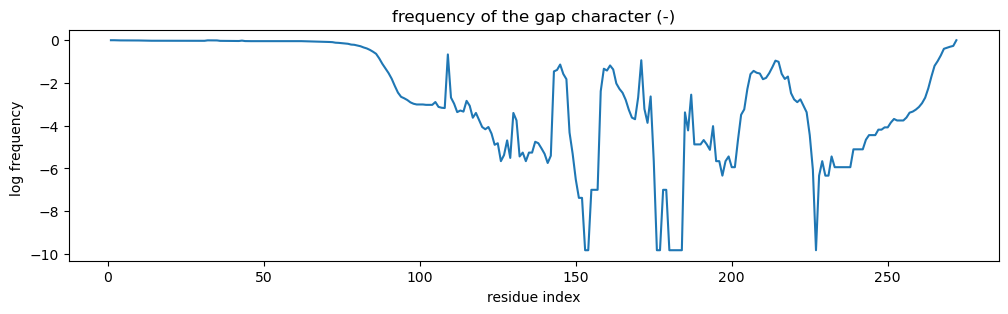

In [5]:
fig = plt.figure(figsize=(12, 3))
plt.plot(np.arange(1, f_ia.shape[0]+1), np.log(f_ia[:, 20]))
plt.title("frequency of the gap character (-)")
plt.xlabel("residue index")
plt.ylabel("log frequency ")
pass

There are too many gap characters in the first one-third of the alignment. When the gap character is almost everything in the alignment, we expect log frequency to be  $\approx \log 1 \approx 0$.

Below, We remove the gap character's frequency and then re-normalize the other frequencies to add up to one. 

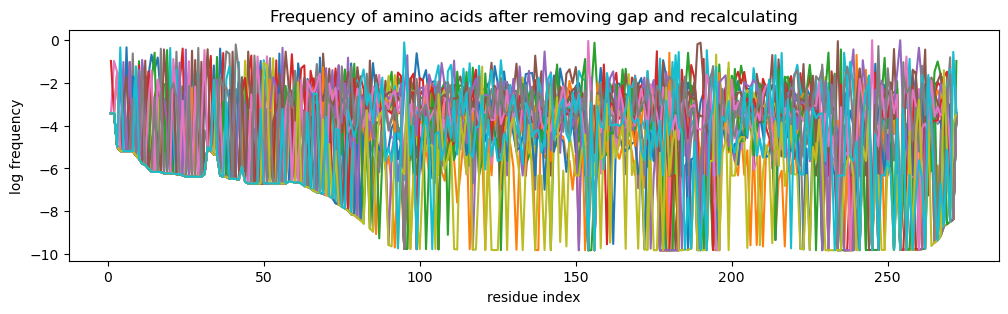

In [6]:
f_ia_nogap = f_ia[:, :20]  / f_ia[:, :20].sum(axis=1)[:, np.newaxis]
h_ia = np.log(f_ia_nogap)
fig = plt.figure(figsize=(12, 3))
plt.plot(np.arange(1, h_ia.shape[0]+1), h_ia)
plt.title("Frequency of amino acids after removing gap and recalculating")
plt.ylabel("log frequency")
plt.xlabel("residue index")
pass

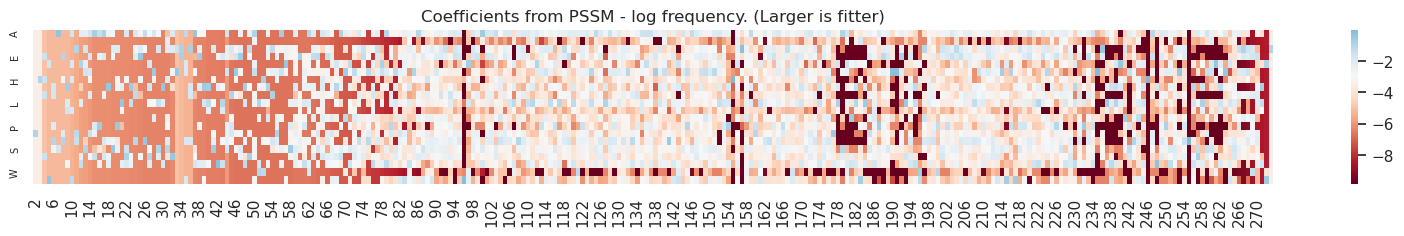

In [7]:
sns.set(font_scale=1)
plt.figure(figsize=(20, 2))
g = sns.heatmap(h_ia.transpose(), square=False, cmap = 'RdBu', 
                center=np.log(0.05)) #, cbar_kws={"shrink": 0.2})
ax = plt.gca()
# reindex x tick labels by adding offset = 2
# first amino acid after the start codon is indexed at 0 so 
# we have to add 2 to get the indexing of the start codon to be 1
xticklabels = [int(x.get_text()) + 2 for x in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels)
# set ytick labels to be amino acids
yticklabels = [DEFAULT_ENCODER.int_to_alpha_dict[int(x.get_text())]
                   for x in ax.get_yticklabels()]
ax.set_yticklabels(yticklabels, fontsize=7)
plt.title("Coefficients from PSSM - log frequency. (Larger is fitter)")
pass

### Load in azidation activity data

In [8]:
model_seqs = pd.read_csv("../output/2D/azid_model_sequences.csv")
model_seqs.head()

,mutants_in_seq,category,count_frac_bin,mut_type,response,dist_parent,sequence_aa
0,D65N;F152L,High Azidation,0.048529,beneficial,3,2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...
1,D65N;G192S,High Azidation,0.112263,NaN,3,2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...
2,NaN,High Azidation,0.109123,NaN,3,0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...
3,A211T;K227I,High Azidation,0.089621,NaN,3,2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...
4,D65N;F152L;K227I,High Azidation,0.088376,beneficial,3,3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...


In [9]:
parent_2d = str(Bio.SeqIO.read("../data/2D/2D.fasta", format="fasta").translate().seq)

In [10]:
# trim the start and stop codon
model_seqs["sequence_aa_trim"] = model_seqs.sequence_aa.str.slice(1, -1)

In [11]:
scipy.stats.spearmanr(model_seqs.response, model_seqs.dist_parent)

SignificanceResult(statistic=-0.39257964186312916, pvalue=7.975638323945017e-11)

In [12]:
scipy.stats.kendalltau(model_seqs.response, model_seqs.dist_parent)

SignificanceResult(statistic=-0.3403675022624173, pvalue=1.5454720264369515e-10)

### Compute PSSM score and compute correlation with azidation activity

In [13]:
# compute PSSM score on the trimmed sequences
model_seqs["pssm_score"] = model_seqs.sequence_aa_trim.map(lambda x:
    -h_ia[np.arange(h_ia.shape[0]), DEFAULT_ENCODER.string_to_np(x)].sum())

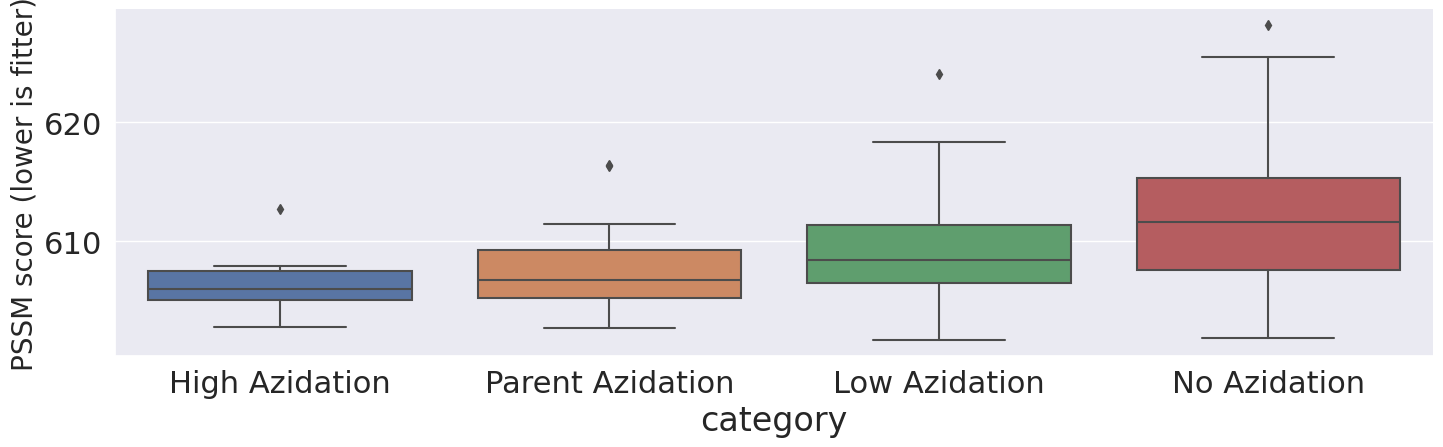

In [14]:
sns.set(font_scale=2)
g = sns.catplot(x='category', y='pssm_score', data=model_seqs, kind="box", aspect=3)
g.set_ylabels('PSSM score (lower is fitter)', fontsize=20)
pass

In [15]:
scipy.stats.spearmanr(-model_seqs.response, model_seqs.pssm_score)

SignificanceResult(statistic=0.37391803564286924, pvalue=6.968662629476672e-10)

In [16]:
scipy.stats.kendalltau(-model_seqs.response, model_seqs.pssm_score)

SignificanceResult(statistic=0.2974574690118192, pvalue=1.3274116602423087e-09)

### Load in bmDCA model

In [17]:
bmDCA_params_dir = "../data/scratch/bmDCA"
e_i_a_j_b = np.load(f"{bmDCA_params_dir}/sadA_e_i_a_j_b.npy")
h_i_a = np.load(f"{bmDCA_params_dir}/sadA_h_i_a.npy")

L = h_i_a.shape[0]

In [18]:
import random
random_prot = "".join(random.choices(list(DEFAULT_ENCODER.alpha_to_int_dict.keys()), k=L))
energy_calc_single(DEFAULT_ENCODER.string_to_np(random_prot), h_i_a=h_i_a, e_i_a_j_b=e_i_a_j_b)

array(-1.57557496)

In [19]:
energy_calc_single(DEFAULT_ENCODER.string_to_np(parent_2d[1:-1]),
                   h_i_a=h_i_a, e_i_a_j_b=e_i_a_j_b)

array(-453.65982796)

In [20]:
# To calculate the DCA score we take the negative of the energy
# This gives us \sum h_i(x_i) + \sum e_ij(x_i, x_j) as the score
# The larger the score the fitter the protein is
model_seqs["dca_score"] = model_seqs.sequence_aa_trim.map(lambda x:
    energy_calc_single(DEFAULT_ENCODER.string_to_np(x), h_i_a=h_i_a, e_i_a_j_b=e_i_a_j_b))

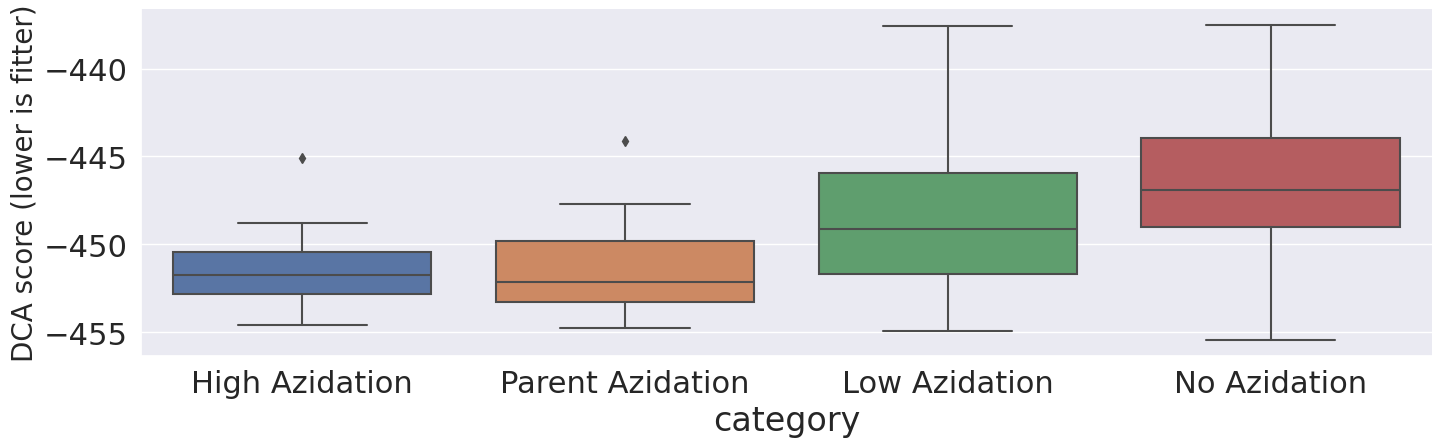

In [21]:
sns.set(font_scale=2)
g = sns.catplot(x='category', y='dca_score', data=model_seqs, kind="box", aspect=3)
g.set_ylabels('DCA score (lower is fitter)', fontsize=20)
pass

In [22]:
scipy.stats.spearmanr(-model_seqs.response, model_seqs.dca_score)

SignificanceResult(statistic=0.415831911250639, pvalue=4.3979419154073206e-12)

In [23]:
scipy.stats.kendalltau(-model_seqs.response, model_seqs.dca_score)

SignificanceResult(statistic=0.32730738792531994, pvalue=2.5118514019048126e-11)

## check correlation with 1-VH, 2-L, 3-VRL libraries

In [24]:
seqs = pd.read_csv("../data/sequences_Oct22.tsv", sep="\t")
seqs_no_dups = seqs.drop_duplicates(["parent", "category", "ss_aa"], keep='first')
parent_seqs = seqs_no_dups[seqs_no_dups.ss_aa == "*0*"].groupby("parent").head(1)
parent_seqs.category = "P"
final_seqs = pd.concat([seqs_no_dups[seqs_no_dups.ss_aa != "*0*" ], parent_seqs])
final_seqs["response"] = final_seqs.category.map({"H":3, "P":2, "L":1, "N":0})
final_seqs


,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category,response
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H,3
1,A679G,18573,1,1,K227E,False,2,1VH,H,3
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H,3
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P,2
6,"A328T,G774T",1200,2,2,"T110S,M258I",False,2,1VH,L,1
...,...,...,...,...,...,...,...,...,...,...
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N,0
1489,"T33C,T123A,A263T,A491T,G690A,C699G",116,6,3,"D41E,K88I,D164V",False,185,3VRL,N,0
3,*0*,11321,0,0,*0*,False,4,1VH,P,2
457,*0*,6378,0,0,*0*,False,1,2L,P,2


In [25]:
# cache the parent sequences in this dictionary
parent_seqs = {parent: utils.get_parent_seq(parent) for parent in final_seqs.parent.unique()}

# map the shortened sequences to full sequences
final_seqs["sequence_aa"] = final_seqs[["ss_aa", "parent"]].apply(lambda x: 
                                    utils.expand_mut_str_list_to_seq(
                                        x['ss_aa'], parent_seqs[x['parent']], 
                                        split_mut_char=",", offset=1), axis=1)

final_seqs["sequence_aa_trim"] = final_seqs.sequence_aa.str.slice(1, -1)

In [26]:
# compute PSSM score on the trimmed sequences
final_seqs["pssm_score"] = final_seqs.sequence_aa_trim.map(lambda x:
    -h_ia[np.arange(h_ia.shape[0]), DEFAULT_ENCODER.string_to_np(x)].sum())

final_seqs["dca_score"] = final_seqs.sequence_aa_trim.map(lambda x:
    energy_calc_single(DEFAULT_ENCODER.string_to_np(x), h_i_a=h_i_a, e_i_a_j_b=e_i_a_j_b))

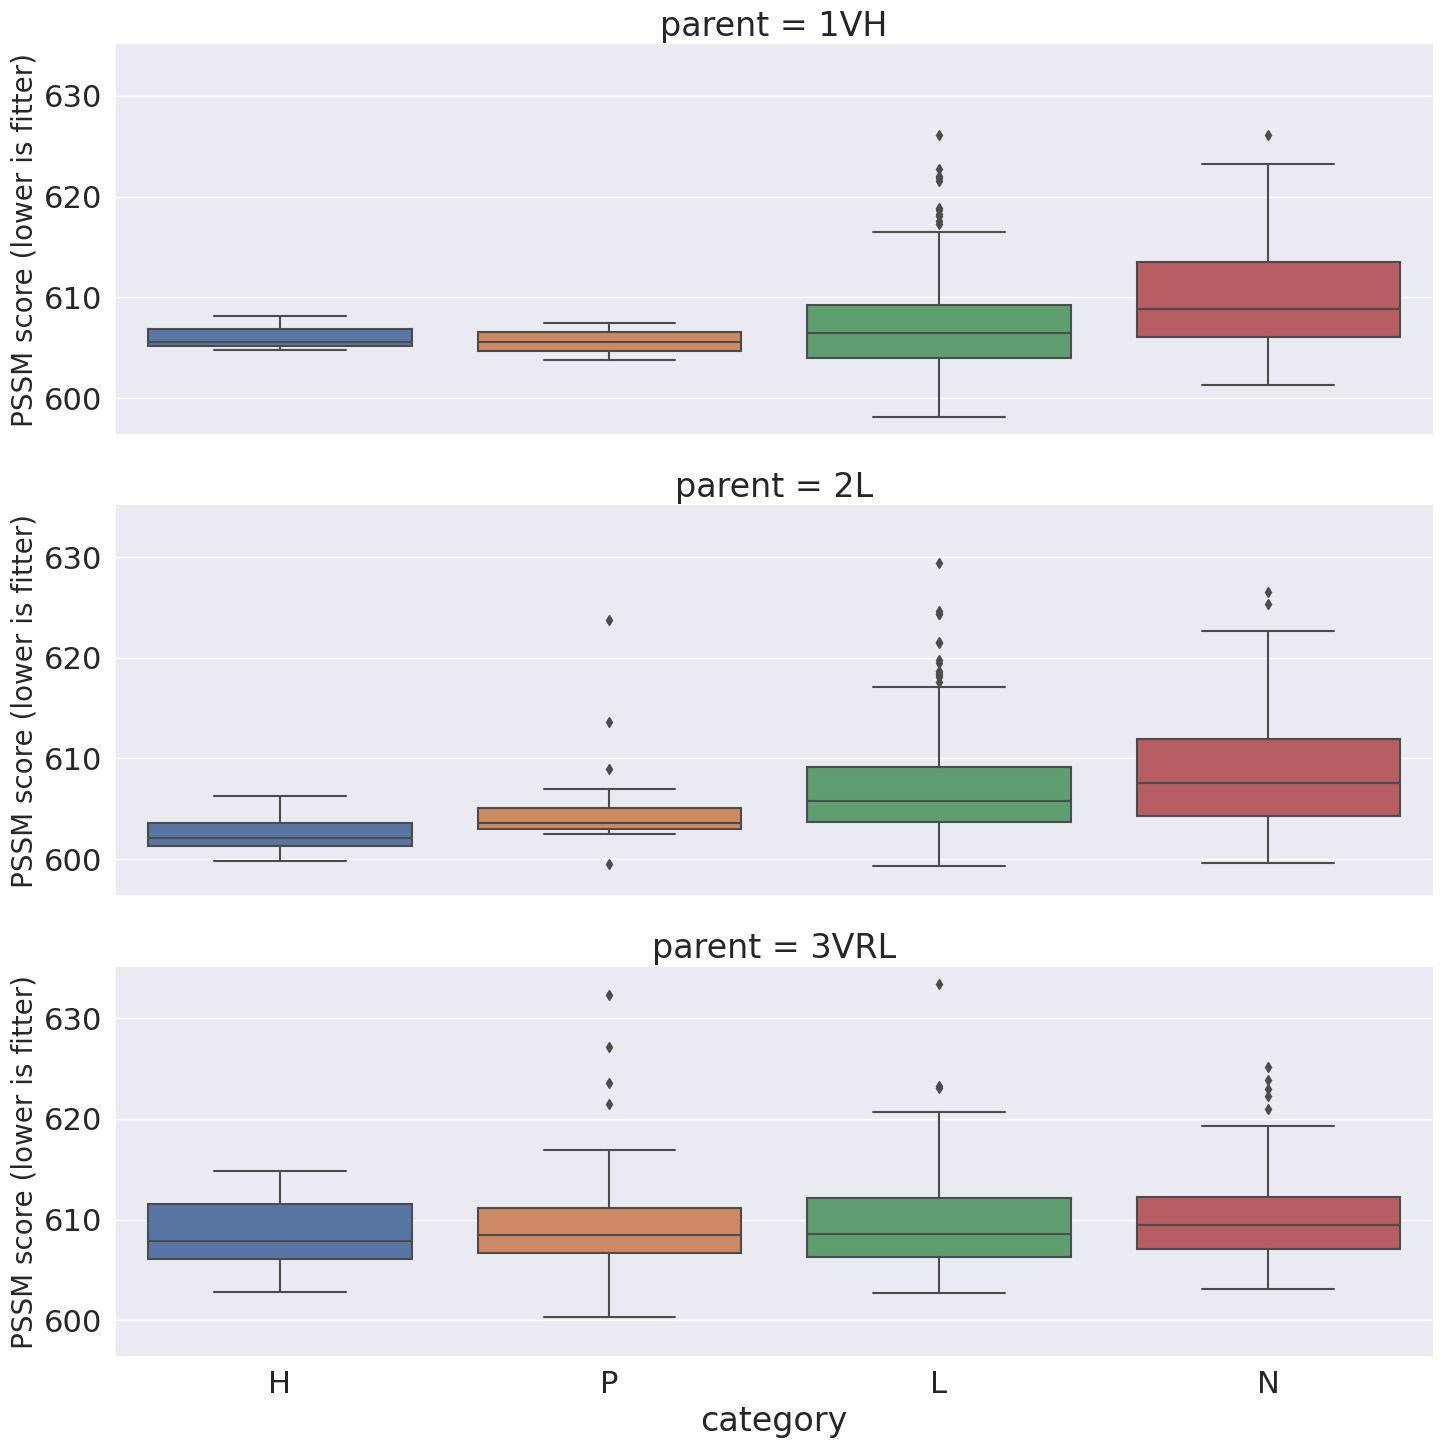

In [27]:
sns.set(font_scale=2)
g = sns.catplot(x='category', y='pssm_score', row="parent", data=final_seqs, kind="box", aspect=3)
g.set_ylabels('PSSM score (lower is fitter)', fontsize=20)
pass

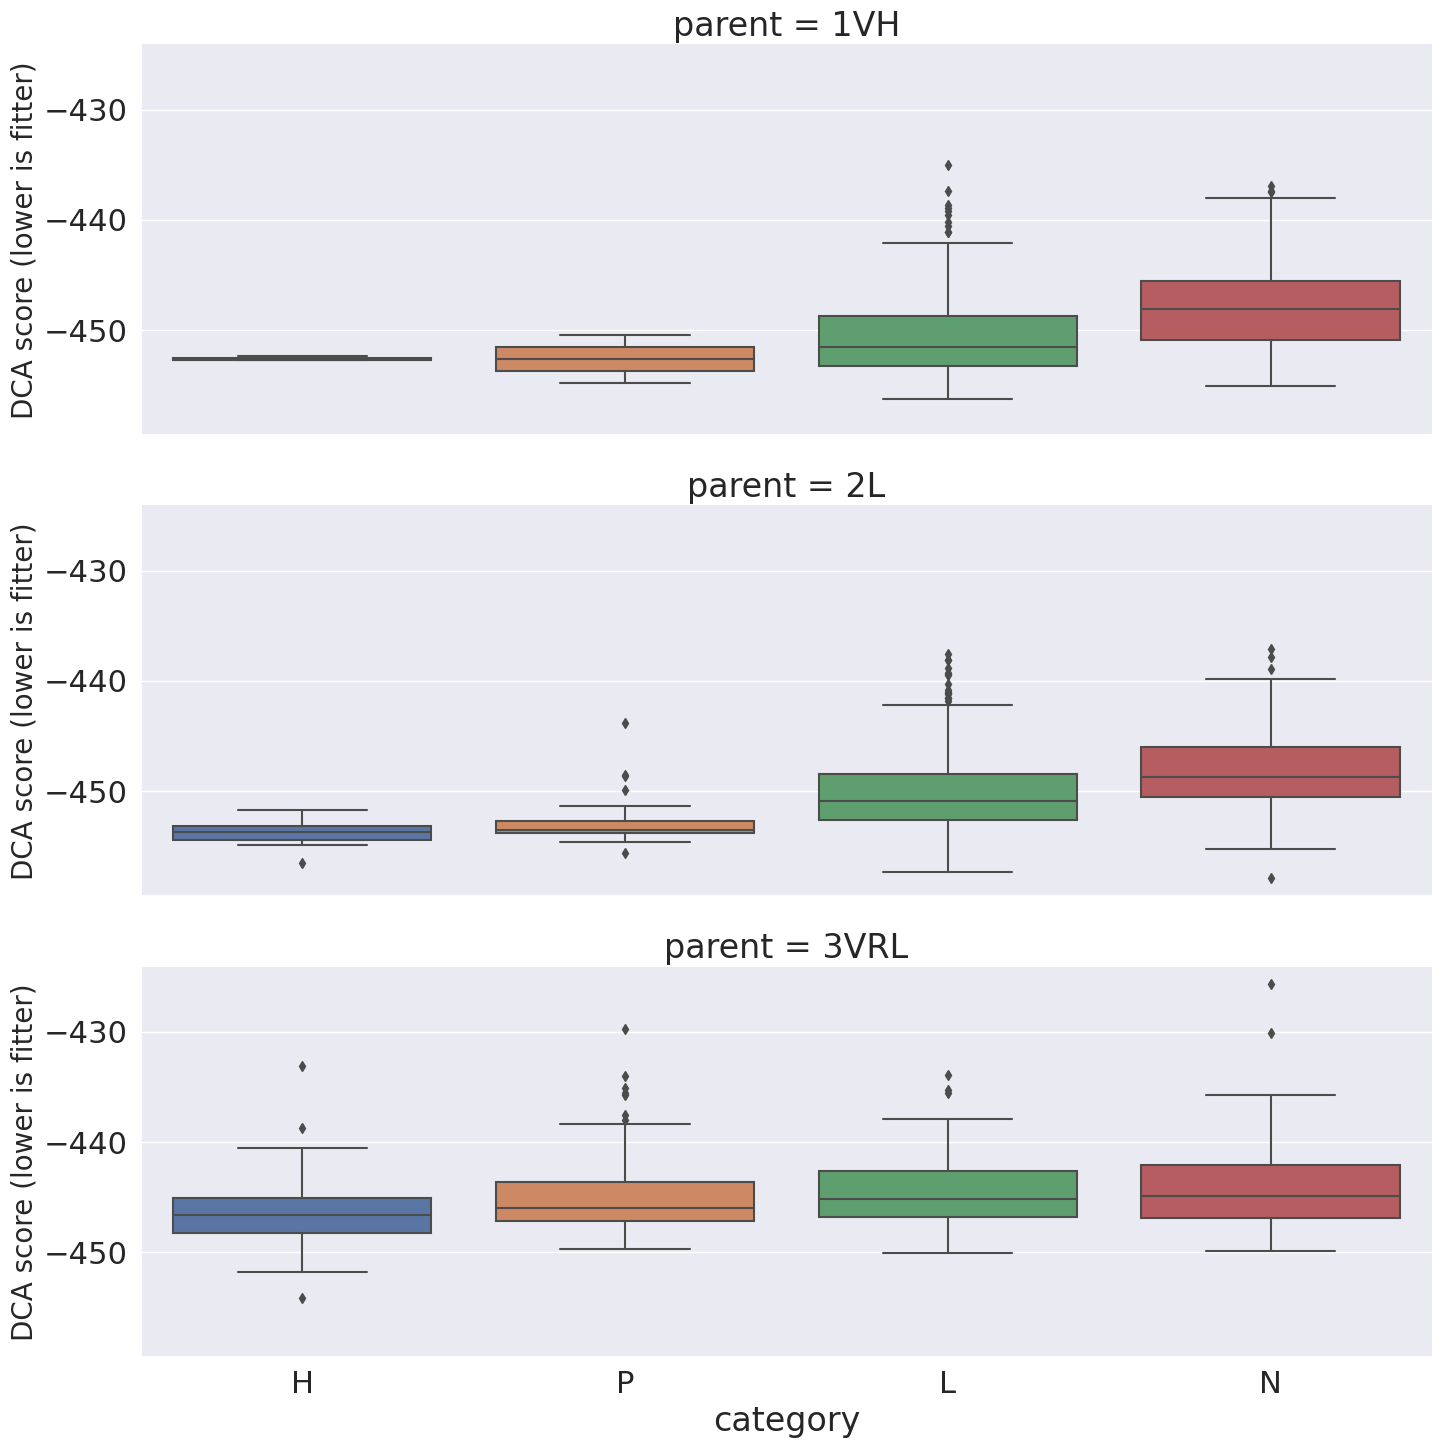

In [28]:
sns.set(font_scale=2)
g = sns.catplot(x='category', y='dca_score', row="parent", data=final_seqs, kind="box", aspect=3)
g.set_ylabels('DCA score (lower is fitter)', fontsize=20)
g.fig.savefig("../output/dca_score_on_screening_data.png", dpi=300)
pass

In [29]:
scipy.stats.spearmanr(-final_seqs.response, final_seqs.pssm_score)

SignificanceResult(statistic=0.16788829842280986, pvalue=7.676413625355762e-10)

In [30]:
scipy.stats.spearmanr(-final_seqs.response, final_seqs.dca_score)

SignificanceResult(statistic=0.15054453167843806, pvalue=3.624780030849912e-08)

In [31]:
# now groupby parent and apply statistics

In [32]:
def f(x):
    d = {}

    sr = scipy.stats.spearmanr(-x.response, x.dca_score)
    d['dca_spearman'] = sr.statistic
    d['dca_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.dca_score)
    d['dca_kendalltau'] = sk.statistic
    d['dca_kendalltau_p'] = sr.pvalue

    sr = scipy.stats.spearmanr(-x.response, x.pssm_score)
    d['pssm_spearman'] = sr.statistic
    d['pssm_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.pssm_score)
    d['pssm_kendalltau'] = sk.statistic
    d['pssm_kendalltau_p'] = sr.pvalue
    

    d['N'] = len(x)
    return pd.Series(d, index=['dca_spearman', 'dca_spearman_p', 
                               'dca_kendalltau', 'dca_kendalltau_p', 
                               'pssm_spearman', 'pssm_spearman_p', 
                               'pssm_kendalltau', 'pssm_kendalltau_p',                     
                               'N'])


parent_aa_dist_stats = final_seqs.groupby(["parent", "aa_dist"]).apply(f)
parent_aa_dist_stats

/home/romeroroot/miniconda3/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4921: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


dca_spearman  dca_spearman_p  dca_kendalltau  \
parent aa_dist                                                 
1VH    0                 NaN             NaN             NaN   
       1            0.266075        0.006871        0.216580   
       2            0.230344        0.015969        0.186995   
       3            0.350164        0.000408        0.287218   
       4           -0.022247        0.878125       -0.018352   
       5            0.010605        0.950329        0.008775   
       6           -0.078446        0.789805       -0.066299   
       7           -0.258199        0.741801       -0.235702   
2L     0                 NaN             NaN             NaN   
       1            0.308721        0.000788        0.249974   
       2            0.313475        0.000130        0.256875   
       3            0.309058        0.001574        0.251396   
       4           -0.045790        0.730565       -0.037703   
       5           -0.045262        0.787288       -0.035675   
       6            0.173205        0.610542        0.147710   
       7            0.774597        0.225403        0.707107   
3VRL   0                 NaN             NaN             NaN   
       1            0.060410        0.467320        0.044016   
       2            0.161067        0.052118        0.121489   
       3            0.191157        0.083432        0.147978   
       4           -0.050674        0.765817       -0.058324   
       5            0.250873        0.386972        0.174485   
       6           -0.683130        0.134702       -0.602464   
       7                 NaN             NaN             NaN   
       8                 NaN             NaN             NaN   

                dca_kendalltau_p  pssm_spearman  pssm_spearman_p  \
parent aa_dist                                                     
1VH    0                     NaN            NaN              NaN   
       1                0.006871       0.148383         0.136652   
       2                0.015969       0.073072         0.450182   
       3                0.000408       0.316816         0.001481   
       4                0.878125      -0.061178         0.672990   
       5                0.950329       0.100745         0.552988   
       6                0.789805      -0.117670         0.688694   
       7                0.741801      -0.258199         0.741801   
2L     0                     NaN            NaN              NaN   
       1                0.000788       0.114812         0.221778   
       2                0.000130       0.277610         0.000755   
       3                0.001574       0.108652         0.277022   
       4                0.730565      -0.205059         0.119235   
       5                0.787288      -0.132679         0.427143   
       6                0.610542      -0.115470         0.735302   
       7                0.225403       0.774597         0.225403   
3VRL   0                     NaN            NaN              NaN   
       1                0.467320       0.043004         0.605029   
       2                0.052118       0.165124         0.046399   
       3                0.083432       0.195184         0.077012   
       4                0.765817      -0.039779         0.815175   
       5                0.386972       0.064510         0.826574   
       6                0.134702      -0.487950         0.326164   
       7                     NaN            NaN              NaN   
       8                     NaN            NaN              NaN   

                pssm_kendalltau  pssm_kendalltau_p      N  
parent aa_dist                                             
1VH    0                    NaN                NaN    1.0  
       1               0.121203           0.136652  102.0  
       2               0.060361           0.450182  109.0  
       3               0.256264           0.001481   98.0  
       4              -0.050468           0.672990   50.0  
       5               0.08336

In [33]:
stats_to_plot = parent_aa_dist_stats[parent_aa_dist_stats.N > 50][["dca_spearman", "dca_spearman_p",
                                                   "pssm_spearman", "pssm_spearman_p"]]

In [34]:
stats_to_plot_melt = pd.melt(stats_to_plot.reset_index(), id_vars = ["parent", "aa_dist"])
stats_to_plot_melt.head()

,parent,aa_dist,variable,value
0,1VH,1,dca_spearman,0.266075
1,1VH,2,dca_spearman,0.230344
2,1VH,3,dca_spearman,0.350164
3,2L,1,dca_spearman,0.308721
4,2L,2,dca_spearman,0.313475


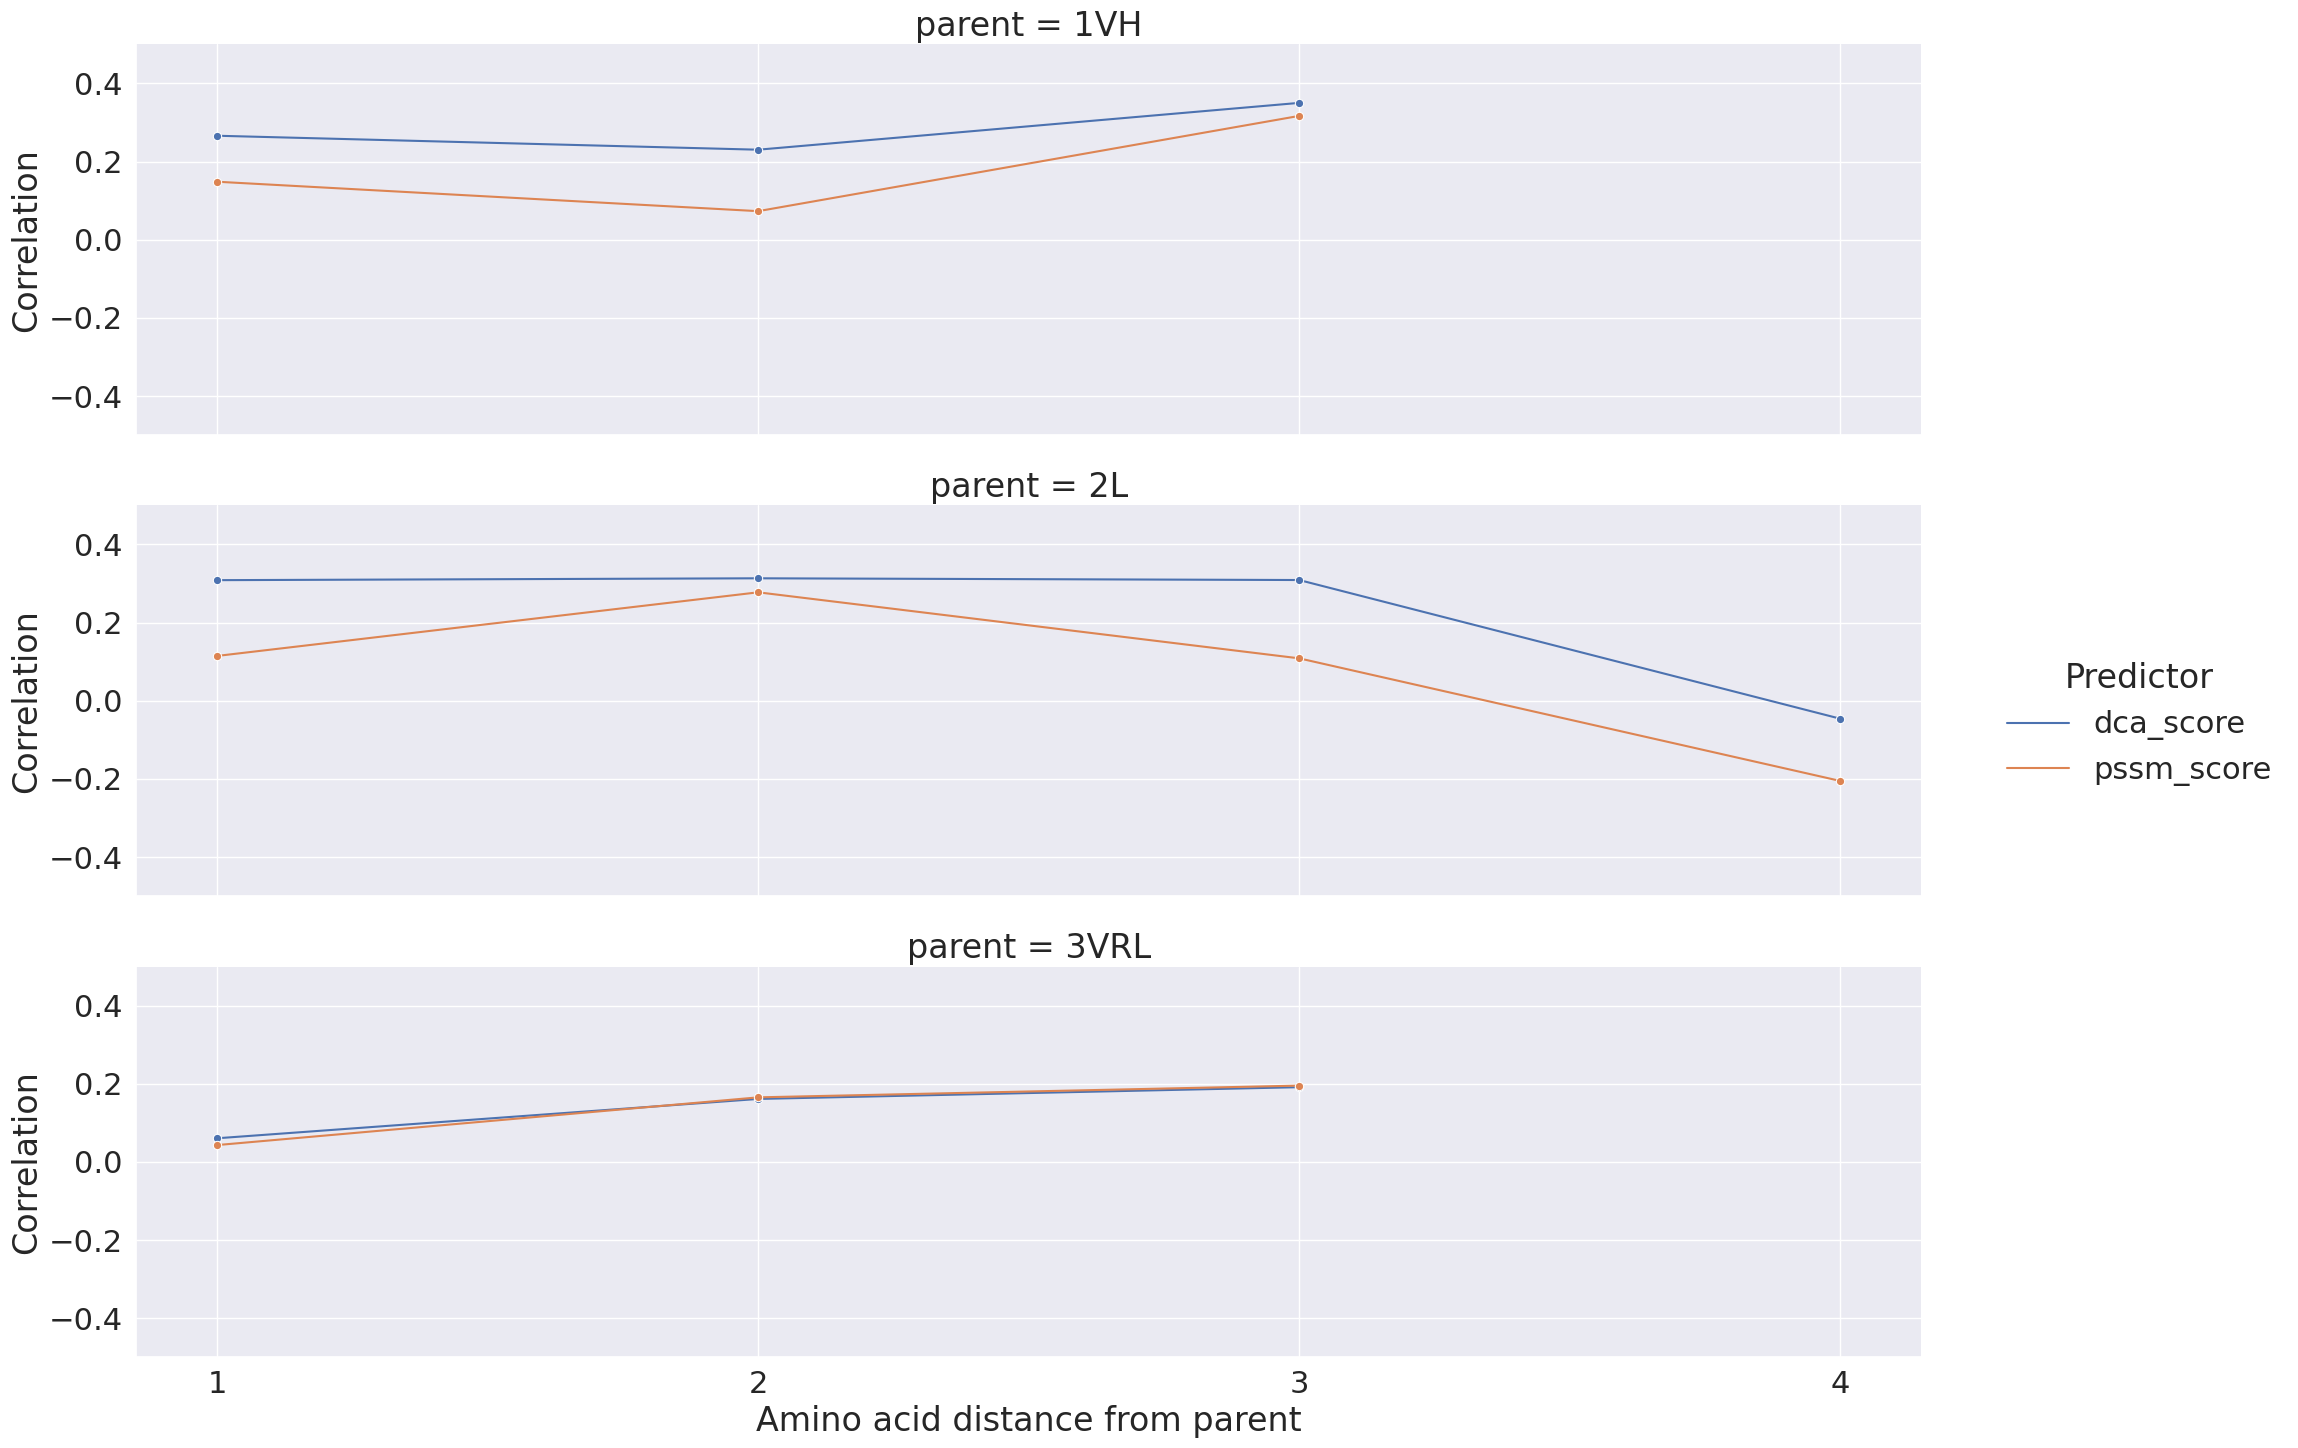

In [35]:
g = sns.relplot(stats_to_plot_melt[~ stats_to_plot_melt.variable.str.endswith("_p")],
            x="aa_dist", y="value", row="parent", hue="variable", kind='line',
                aspect=4, marker='o')
_ = [ax.xaxis.set_major_locator(MaxNLocator(integer=True)) for ax in g.axes.flatten()]
g.set(ylabel="Correlation", ylim=(-0.5, 0.5), xlabel="Amino acid distance from parent")
g._legend.set_title("Predictor")
# replace labels
new_labels = ['dca_score', 'pssm_score']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
    
g.fig.savefig("../output/dca_score_on_screening_data_mutation_adjusted.png", dpi=300)
pass

### Save sequences

Save all the sequences. Also save train/test/validataion splits that are stratified so that they have the same number of sequences from each library. 

In [36]:
final_seqs.columns

Index(['ss_dna', 'dna_count', 'dna_dist', 'aa_dist', 'ss_aa', 'early_stop',
       'seq_rank', 'parent', 'category', 'response', 'sequence_aa',
       'sequence_aa_trim', 'pssm_score', 'dca_score'],
      dtype='object')

In [37]:
(final_seqs[["parent", "category", "response", "dca_score", "sequence_aa_trim"]]
     .to_csv("../output/ordinal_Oct22_sequences_with_dca_score.csv", index=False))

In [38]:
import sklearn.model_selection

seed = 12345
np.random.seed(seed)

In [39]:
N = len(final_seqs)
train_size = int(N * 0.7)
val_size = int(N * 0.85) - train_size
test_size = N - train_size - val_size


train_val_seqs, test_seqs = \
    sklearn.model_selection.train_test_split(final_seqs, test_size = test_size, 
                                         train_size = (train_size + val_size), 
                                         random_state=seed, stratify=final_seqs.parent)

train_seqs, val_seqs = \
    sklearn.model_selection.train_test_split(train_val_seqs, test_size = val_size, 
                                         train_size = train_size, 
                                         random_state=seed+1, stratify=train_val_seqs.parent)

In [40]:
train_seqs.parent.value_counts() / len(train_seqs)

2L      0.357759
3VRL    0.328664
1VH     0.313578
Name: parent, dtype: float64

In [41]:
val_seqs.parent.value_counts() / len(val_seqs)

2L      0.356784
3VRL    0.331658
1VH     0.311558
Name: parent, dtype: float64

In [42]:
test_seqs.parent.value_counts() / len(test_seqs)

2L      0.356784
3VRL    0.331658
1VH     0.311558
Name: parent, dtype: float64

In [43]:
train_seqs.index.to_numpy().tofile(
    "../output/ordinal_Oct22_sequences_with_dca_score_train.txt", sep="\n")
val_seqs.index.to_numpy().tofile(
    "../output/ordinal_Oct22_sequences_with_dca_score_val.txt", sep="\n")
test_seqs.index.to_numpy().tofile(
    "../output/ordinal_Oct22_sequences_with_dca_score_test.txt", sep="\n")
